# Handwriting anylasis - CS Coursework 2026 

by Aarush

#### Start by importing some of the required libraries 

* [`torchvision`](https://docs.pytorch.org/vision/stable/index.html) - base domain library for computer vision
* `torchvision.datasets` - get datasets and loading functions for computer vision here
* `torchvision.models` - get pre-trained computer vision models
* `torchvision.transforms` - funcitons for manipulating your vision data to be suitable for use for a ML model
* `torch.utils.data.Dataset` - Base dataset class for pytorch
* `torch.utils.data.Dataloader` - Creates a python iterable over a dataset

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torchvision
from torchvision import transforms 
from torchvision import datasets
from torchvision.transforms import ToTensor 

print(torch.__version__)
print(torchvision.__version__)


2.10.0+cu128
0.25.0+cu128


In [2]:
!nvidia-smi

Sat Mar  7 18:27:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# Device agnostic code to utilise the GPU if available 
if torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'

### Getting a Dataset
Using the MNIST dataset through Imagenet -> root, train, download, transform , target_transform 
https://docs.pytorch.org/vision/stable/datasets.html

In [4]:
train_data = datasets.MNIST(
    root='data',
    train=True,
    download=True,
    transform=ToTensor(),# dataset comes in PIL format so we need to transfrorm into tensors for analysis
    target_transform =None
)

test_data = datasets.MNIST(
    root='data',
    train= False,
    download = True,
    transform = ToTensor()
)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.13MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.3MB/s]


In [ ]:
len(train_data), len(test_data)

(60000, 10000)

In [6]:
# view data as tensors and see the first training image
image, label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

In [7]:
# understand the data by checking shape of tensor 
print(f'Image shape: {image.shape}')

Image shape: torch.Size([1, 28, 28])


Text(0.5, 1.0, '5')

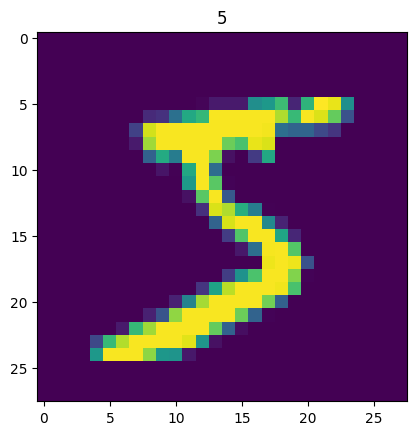

In [8]:
# Convert the tensor into an image that we can view in order to visualise 
plt.imshow(image.squeeze());
plt.title(label)

In [ ]:
class_names = train_data.classes
class_names

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

In [10]:
class_index = train_data.class_to_idx # turn into a dictionary to map the label to its
class_index

{'0 - zero': 0,
 '1 - one': 1,
 '2 - two': 2,
 '3 - three': 3,
 '4 - four': 4,
 '5 - five': 5,
 '6 - six': 6,
 '7 - seven': 7,
 '8 - eight': 8,
 '9 - nine': 9}

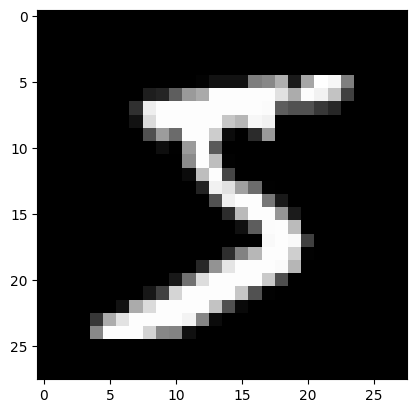

In [11]:
plt.imshow(image.squeeze(), cmap = 'grey')

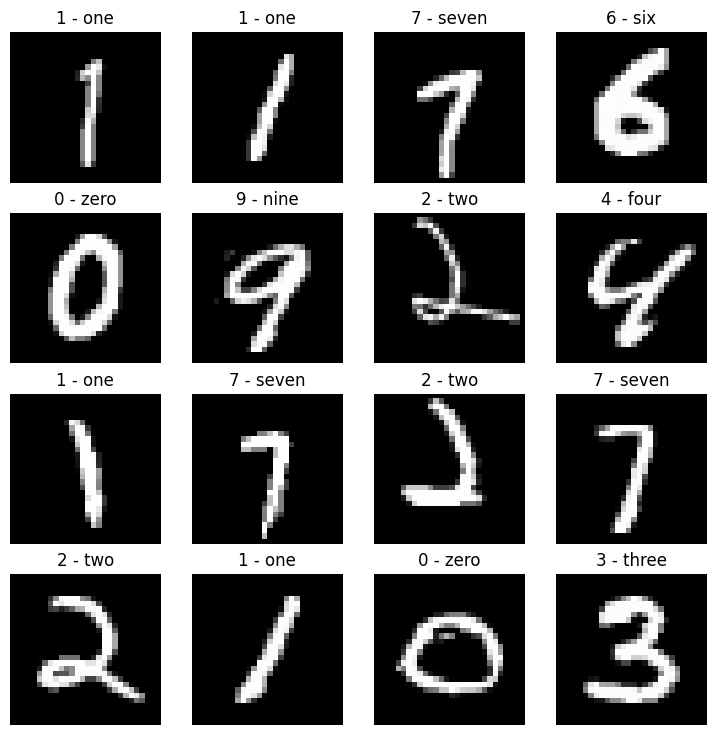

In [12]:
# visualise multiple examples to get better understanding of the data:
torch.manual_seed(18)
fig =plt.figure(figsize=(9,9))
rows , cols = 4,4
for i in range (1,rows* cols+1):
    random_index = torch.randint(0,len(train_data), size = [1]).item() # returns view 
    image, label = train_data[random_index]
    fig.add_subplot(rows, cols, i )
    plt.imshow(image.squeeze(), cmap ='grey')
    plt.title(class_names[label])
    plt.axis(False);

In [13]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32 #hyperparameter so capitalised (standard)

train_dataloader = DataLoader(
    dataset= train_data,
    batch_size = BATCH_SIZE,
    shuffle = True 
)

test_dataloader = DataLoader(
    dataset= test_data,
    batch_size = BATCH_SIZE,
    shuffle = False
)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x78884c528260>,
 <torch.utils.data.dataloader.DataLoader at 0x78884da736e0>)

In [ ]:
train_x_batch , train_Y_batch = next(iter(train_dataloader))
train_x_batch.shape, train_Y_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

### Baseline Model (linear)

In [15]:
class MNISTV1 (nn.Module):
    def __init__(self, input_shape: int , hidden_units : int , output_shape :int ):
        super().__init__()
        self.layer_stack= nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features = input_shape, out_features = hidden_units),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )
    def forward(self,x):
        return self.layer_stack(x)


In [ ]:
model_0 = MNISTV1(input_shape = 28*28, hidden_units = 10, output_shape = 10)
model_0.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0174,  0.0197,  0.0294,  ..., -0.0191,  0.0168, -0.0267],
                      [-0.0310,  0.0275, -0.0269,  ..., -0.0350,  0.0159, -0.0329],
                      [ 0.0180, -0.0317, -0.0210,  ..., -0.0183, -0.0284,  0.0099],
                      ...,
                      [-0.0224,  0.0158, -0.0107,  ..., -0.0060,  0.0060,  0.0085],
                      [-0.0072, -0.0212, -0.0241,  ..., -0.0267,  0.0181,  0.0051],
                      [-0.0166,  0.0285,  0.0157,  ..., -0.0091, -0.0076, -0.0225]])),
             ('layer_stack.1.bias',
              tensor([ 0.0109, -0.0275,  0.0268,  0.0356,  0.0193,  0.0138,  0.0138, -0.0089,
                      -0.0273, -0.0297])),
             ('layer_stack.2.weight',
              tensor([[ 0.2244,  0.0697,  0.0964, -0.2662,  0.1779,  0.0800, -0.1795,  0.2206,
                        0.0124,  0.2612],
                      [-0.2565,  0.3074,  0.2580, -0.0913, -0.1285,  0.0678,  0.

In [ ]:
model_0

MNISTV1(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): Linear(in_features=10, out_features=10, bias=True)
  )
)

### LossFn and Optmisation metrics :

In [18]:
import requests
from pathlib import Path


if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

In [ ]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimiser = torch.optim.SGD(params=model_0.parameters(), lr = 0.1)# lr is hyperparameter

# timing experiments

from timeit import default_timer as timer 



In [20]:
# testing with dummy data :
dummy_x = torch.rand([1,1,28,28])
model_0(dummy_x)

tensor([[ 0.1686, -0.1098,  0.4057, -0.2297,  0.0023,  0.0082, -0.2000, -0.1262,
         -0.3652, -0.0335]], grad_fn=<AddmmBackward0>)

In [21]:
from timeit import default_timer as timer
def print_train_time(start: float,
                     end: float,
                     device : torch.device = None):
    '''
    Prints Difference between start and end time.
    '''
    total_time = end - start
    print(f'Train time on {device}: {total_time:.3f}seconds')
    return total_time 

## Make training loop with batches

In [ ]:
train_dataloader.dataset

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [23]:
# create a training loop and time it # progress bar
from tqdm.auto import tqdm # progress bar for training loop
torch.manual_seed(18)
train_time_start_0 = timer()

epochs = 3 

for epoch in tqdm(range(epochs)):
    print(f'Epoch : {epoch}\n---------------')

    train_loss, train_acc = 0 , 0 
    for batch, (X ,y) in enumerate(train_dataloader):
        model_0.train()

        y_pred = model_0(X)
        loss = loss_fn(y_pred,y)
        train_acc += accuracy_fn(y_true=y,y_pred=y_pred.argmax(dim=1))
        train_loss += loss
        optimiser.zero_grad()
        loss.backward()
        optimiser.step()

        if batch % 200 ==0:
            print(f'Batch: {batch * len(X)}/{len(train_dataloader.dataset)} samples')

    # avg loss per epoch 
    train_loss /= len(train_dataloader)
    train_acc /= len(train_dataloader)
    

    # testing
    test_loss, test_acc = 0,0
    model_0.eval()
    with torch.inference_mode():
        for (X_test,y_test) in (test_dataloader):
            test_pred = model_0(X_test)

            loss = loss_fn(test_pred , y_test)
            test_loss += loss

            test_acc += accuracy_fn(y_true=y_test,y_pred=test_pred.argmax(dim=1))
        
        test_loss /= len(test_dataloader)

        test_acc /= len(test_dataloader)
    print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")

train_time_end_0 = timer()
total_train_time_model_0 = print_train_time(start = train_time_start_0,
                                            end= train_time_end_0,
                                            device = str(next(model_0.parameters()).device))






  0%|          | 0/3 [00:00<?, ?it/s]

Epoch : 0
---------------
Batch: 0/60000 samples
Batch: 6400/60000 samples
Batch: 12800/60000 samples
Batch: 19200/60000 samples
Batch: 25600/60000 samples
Batch: 32000/60000 samples
Batch: 38400/60000 samples
Batch: 44800/60000 samples
Batch: 51200/60000 samples
Batch: 57600/60000 samples

Train loss: 0.44556 | Test loss: 0.32646, Test acc: 90.86%

Epoch : 1
---------------
Batch: 0/60000 samples
Batch: 6400/60000 samples
Batch: 12800/60000 samples
Batch: 19200/60000 samples
Batch: 25600/60000 samples
Batch: 32000/60000 samples
Batch: 38400/60000 samples
Batch: 44800/60000 samples
Batch: 51200/60000 samples
Batch: 57600/60000 samples

Train loss: 0.33200 | Test loss: 0.31290, Test acc: 91.20%

Epoch : 2
---------------
Batch: 0/60000 samples
Batch: 6400/60000 samples
Batch: 12800/60000 samples
Batch: 19200/60000 samples
Batch: 25600/60000 samples
Batch: 32000/60000 samples
Batch: 38400/60000 samples
Batch: 44800/60000 samples
Batch: 51200/60000 samples
Batch: 57600/60000 samples

Trai

Predicted label: 0
Class 0: 0.9997
Class 1: 0.0000
Class 2: 0.0000
Class 3: 0.0000
Class 4: 0.0000
Class 5: 0.0002
Class 6: 0.0001
Class 7: 0.0000
Class 8: 0.0000
Class 9: 0.0000


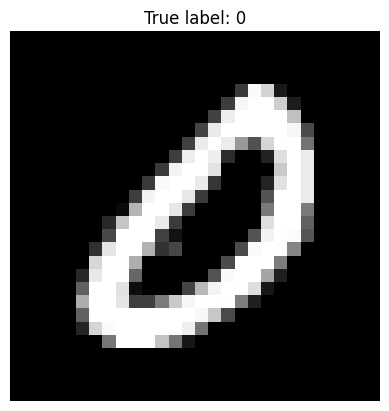

In [24]:
import random
random_idx = random.randint(0, len(test_data) - 1)
image, label = test_data[random_idx]

plt.imshow(image.squeeze(), cmap='grey')
plt.title(f"True label: {label}")
plt.axis('off')

model_0.eval()
with torch.no_grad():
    pred = model_0(image.unsqueeze(0))  
    pred_label = pred.argmax(dim=1).item()
    print(f"Predicted label: {pred_label}")

probabilities = torch.softmax(pred, dim=1).squeeze()
for i, prob in enumerate(probabilities):
    print(f"Class {i}: {prob:.4f}")

## Training / testing loop function


In [25]:
import torch.nn as nn

# functionising the training loop
def train_step(model : torch.nn.Module,
               loss_fn : torch.nn.Module,
               optimizer : torch.optim.Optimizer,
               data_loader : torch.utils.data.DataLoader,
               accuracy_fn,
               device : torch.device = device
               ):
  
  train_loss, train_acc = 0,0
  model.to(device)
  for batch,(X,y) in enumerate(data_loader):
    X,y = X.to(device), y.to(device)
    model.train()
    y_pred = model(X)

    loss = loss_fn(y_pred, y) 
    train_loss += loss.item()
    train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim = 1))

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

  train_acc /= len(data_loader)
  train_loss /= len(data_loader)
  print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")


def test_step(model : torch.nn.Module,
              loss_fn: torch.nn.Module,
              data_loader : torch.utils.data.DataLoader,
              accuracy_fn,
              device : torch.device = device
              ):
  test_loss ,test_acc = 0,0
  model.to(device)
  model.eval()
  with torch.inference_mode():
    for X,y in data_loader:
      X,y = X.to(device), y.to(device)
      test_pred = model(X)
      test_loss += loss_fn(test_pred, y).item() 
      test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1)) 

    # average over batches
    test_loss /= len(data_loader)
    test_acc /= len(data_loader)

    print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")

## Non linear model model_1

In [26]:
class MNISTV2(nn.Module):
    def __init__(self, input_features , output_features , hidden_units):
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features = input_features, out_features= hidden_units),
            nn.ReLU(),
            nn.Linear(in_features = hidden_units, out_features= hidden_units),
            nn.ReLU(),
            nn.Linear(in_features = hidden_units, out_features= output_features),
            nn.ReLU()
            )
    def forward(self,x):
        return self.linear_layer_stack(x)

In [27]:
model_1 = MNISTV2(input_features = 28*28, output_features = 10, hidden_units = 64)
model_1.state_dict()

OrderedDict([('linear_layer_stack.1.weight',
              tensor([[-0.0181,  0.0091,  0.0174,  ...,  0.0094, -0.0307, -0.0191],
                      [ 0.0168, -0.0267, -0.0310,  ..., -0.0066, -0.0318, -0.0350],
                      [ 0.0159, -0.0329,  0.0180,  ...,  0.0285, -0.0332, -0.0183],
                      ...,
                      [-0.0317,  0.0190,  0.0286,  ...,  0.0210, -0.0094,  0.0356],
                      [-0.0351,  0.0106, -0.0215,  ..., -0.0040,  0.0302, -0.0318],
                      [ 0.0187, -0.0120, -0.0299,  ...,  0.0355,  0.0043,  0.0243]])),
             ('linear_layer_stack.1.bias',
              tensor([ 0.0267,  0.0047, -0.0134,  0.0255,  0.0336, -0.0248, -0.0085,  0.0213,
                      -0.0309, -0.0135,  0.0319, -0.0034, -0.0102, -0.0076,  0.0207, -0.0242,
                      -0.0090, -0.0115, -0.0170, -0.0157, -0.0075,  0.0316, -0.0275, -0.0155,
                       0.0209, -0.0173, -0.0268,  0.0093, -0.0191,  0.0023, -0.0140,  0.0309,
  

In [28]:
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_1.parameters(), lr = 0.1)

In [ ]:
# Measure time
from timeit import default_timer as timer
train_time_start_on_gpu = timer()

epochs = 10
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    train_step(model=model_1,
               loss_fn=loss_fn,
               optimizer=optimizer,
               data_loader=train_dataloader,
               accuracy_fn=accuracy_fn
    )
    test_step(data_loader=test_dataloader,
        model=model_1,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn
    )

train_time_end_on_gpu = timer()
total_train_time_model_1 = print_train_time(start=train_time_start_on_gpu,
                                            end=train_time_end_on_gpu,
                                            device=device)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 0
---------
Train loss: 0.65843 | Train accuracy: 79.06%
Test loss: 0.39580 | Test accuracy: 86.33%

Epoch: 1
---------
Train loss: 0.37175 | Train accuracy: 86.93%
Test loss: 0.33885 | Test accuracy: 87.93%

Epoch: 2
---------
Train loss: 0.32227 | Train accuracy: 88.16%
Test loss: 0.36196 | Test accuracy: 86.78%

Epoch: 3
---------
Train loss: 0.29590 | Train accuracy: 88.79%
Test loss: 0.30600 | Test accuracy: 88.62%

Epoch: 4
---------
Train loss: 0.28248 | Train accuracy: 89.05%
Test loss: 0.29984 | Test accuracy: 88.57%

Epoch: 5
---------
Train loss: 0.27097 | Train accuracy: 89.39%
Test loss: 0.30479 | Test accuracy: 88.54%

Epoch: 6
---------
Train loss: 0.26226 | Train accuracy: 89.61%
Test loss: 0.29039 | Test accuracy: 88.93%

Epoch: 7
---------
Train loss: 0.25474 | Train accuracy: 89.80%
Test loss: 0.29958 | Test accuracy: 88.70%

Epoch: 8
---------
Train loss: 0.24980 | Train accuracy: 89.88%
Test loss: 0.31033 | Test accuracy: 88.44%

Epoch: 9
---------
Train los

## Adopting a Convolutional Neural Network (CNN) architecture for MNIST


In [ ]:
class MNISTV3(nn.Module):
    def __init__ (self, input_shape : int , hidden_units : int , output_shape : int):
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(
                in_channels = input_shape,
                out_channels = hidden_units,
                kernel_size = 3,
                stride = 1,
                padding = 1 
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels = hidden_units,
                out_channels = hidden_units,
                kernel_size = 3,
                stride = 1,
                padding = 1 
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(
                in_channels = hidden_units,
                out_channels = hidden_units,
                kernel_size = 3,
                stride = 1,
                padding = 1 
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels = hidden_units,
                out_channels = hidden_units,
                kernel_size = 3,
                stride = 1,
                padding = 1 
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*7*7,
                      out_features = output_shape)
        )
    def forward(self,x):
        x = self.conv_block_1(x)
        
        x = self.conv_block_2(x)
        
        x = self.classifier(x)
        
        return x

In [41]:
model_2 = MNISTV3(input_shape= 1,
                  hidden_units = 10,
                  output_shape=len(class_names)).to(device)
model_2

MNISTV3(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [42]:
# loss_fn and optimiser 
loss_fn = nn.CrossEntropyLoss()
optimiser = torch.optim.SGD(params = model_2.parameters(), lr= 0.1)

In [46]:
# train/ test loop :
from timeit import default_timer as timer 
torch.manual_seed(18)
torch.cuda.manual_seed(18)
train_time_start = timer()
epochs = 10

for epoch in tqdm(range(epochs)):
    print(f'Epoch: {epoch}\n---------------')
    train_step(model=model_2,
               loss_fn= loss_fn,
               optimizer=optimiser,
               data_loader=train_dataloader,
               accuracy_fn=accuracy_fn)
    test_step(model=model_2,
               loss_fn= loss_fn,
               data_loader=test_dataloader,
               accuracy_fn=accuracy_fn)
    train_time_end = timer()
    total_time = print_train_time(start=train_time_start, end= train_time_end)

    

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 0
---------------
Train loss: 0.04444 | Train accuracy: 98.61%
Test loss: 0.04846 | Test accuracy: 98.41%

Train time on None: 12.020seconds
Epoch: 1
---------------
Train loss: 0.04020 | Train accuracy: 98.73%
Test loss: 0.03773 | Test accuracy: 98.69%

Train time on None: 23.842seconds
Epoch: 2
---------------
Train loss: 0.03708 | Train accuracy: 98.83%
Test loss: 0.03704 | Test accuracy: 98.79%

Train time on None: 35.609seconds
Epoch: 3
---------------
Train loss: 0.03352 | Train accuracy: 98.95%
Test loss: 0.04101 | Test accuracy: 98.73%

Train time on None: 47.423seconds
Epoch: 4
---------------
Train loss: 0.03160 | Train accuracy: 99.01%
Test loss: 0.05224 | Test accuracy: 98.23%

Train time on None: 59.210seconds
Epoch: 5
---------------
Train loss: 0.02997 | Train accuracy: 99.03%
Test loss: 0.03619 | Test accuracy: 98.90%

Train time on None: 71.006seconds
Epoch: 6
---------------
Train loss: 0.02755 | Train accuracy: 99.12%
Test loss: 0.03212 | Test accuracy: 98.91%

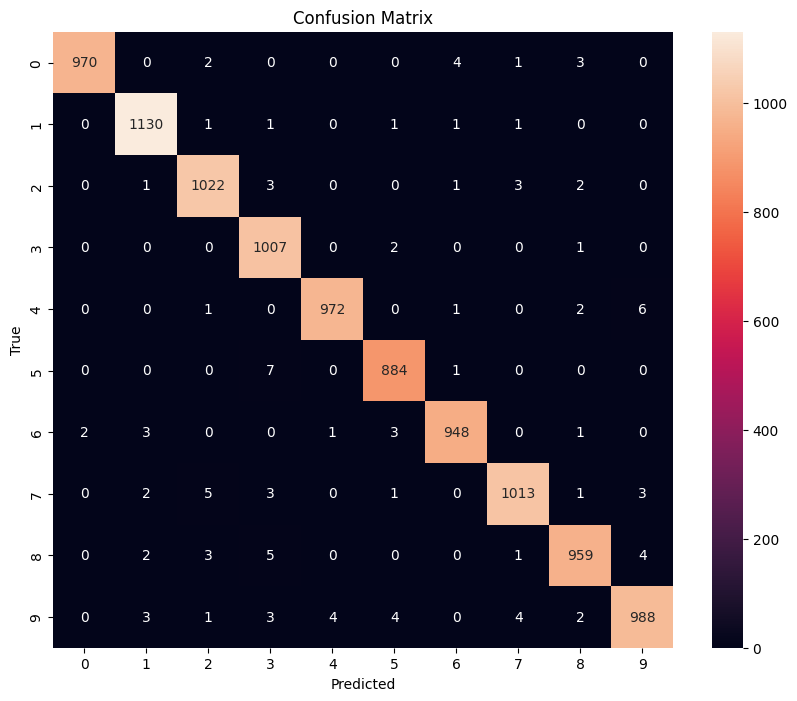

In [47]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_preds = []
all_labels = []

model_2.eval()
with torch.inference_mode():
    for X, y in test_dataloader:
        X, y = X.to(device), y.to(device)
        preds = model_2(X).argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=range(10), 
            yticklabels=range(10))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()